In [1]:
import torch

from scimba.equations.domain import SpaceDomain, SquareDomain
from scimba.equations.pdes import AbstractPDEtx

class ParamHeatPDE1D(AbstractPDEtx):
    """
    Equation:
        \frac{du}{dt} - \alpha \frac{d^2u}{dx^2} =0
    sur :math:`x\in [0,2], t\in[,0.03], \alpha\in [0.4,0.7]`
    We learn :math:`u(t,x,\alpha)`
    parametric model :math:`u_{net} = u_0 + x(2-x)t \cdot u_{\theta}(t,x)`
    """

    def __init__(
        self,
        tdomain=[0, 0.03],
        xdomain=SpaceDomain(1, SquareDomain(1, [[0.0, 2.0]])),
        p_domain=[[0.4, 0.7]],
    ):
        super().__init__(
            nb_unknowns=1,
            time_domain=tdomain,
            space_domain=xdomain,
            nb_parameters=1,
            parameter_domain=p_domain,
        )

        self.first_derivative_t = True
        self.second_derivative_t = False
        self.first_derivative_x = True
        self.second_derivative_x = True
        self.t_min, self.t_max = self.time_domain

    def residual(self, w, t, x, mu, **kwargs):
        alpha = self.get_parameters(mu)
        u_xx = self.get_variables(w, "w_xx")
        u_t = self.get_variables(w, "w_t")
        return u_t - alpha * u_xx

    def bc_residual(self, w, t, x, mu, **kwargs):
        u = self.get_variables(w)
        return u

    def initial_condition(self, x, mu, **kwargs):
        x = x.get_coordinates()

        t0 = 0.02
        alpha = self.get_parameters(mu)

        return (1.0 / ((4.0 * torch.pi * alpha * (t0)) ** 0.5)) * torch.exp(
            -((x - 1) ** 2.0) / (4 * alpha * t0)
        )

    def post_processing(self, t, x, mu, w):
        x_ = x.get_coordinates()
        return self.initial_condition(x, mu) + x_ * (2 - x_) * t * w

    def make_data(self, n_data):
        pass

    def reference_solution(self, t, x, mu):
        x_ = x.get_coordinates()
        t0 = 0.02
        alpha = self.get_parameters(mu)
        return (1.0 / ((4.0 * torch.pi * alpha * (t + t0)) ** 0.5)) * torch.exp(
            -((x_ - 1) ** 2.0) / (4 * alpha * (t + t0))
        )


Using device: cpu


>> load network /home/u4/csmi/2024/he/FEMPIMM/MiniExamples/networks/test.pth
network was not loaded from file: training needed
epoch     0: current loss = 4.39e+02
epoch     0: best loss = 4.39e+02
epoch     1: best loss = 4.37e+02
epoch    14: best loss = 4.00e+02
epoch    16: best loss = 4.00e+02
epoch    14: best loss = 4.00e+02
epoch    16: best loss = 4.00e+02
epoch    18: best loss = 3.92e+02
epoch    19: best loss = 3.82e+02
epoch    18: best loss = 3.92e+02
epoch    19: best loss = 3.82e+02
epoch    21: best loss = 3.79e+02
epoch    22: best loss = 3.66e+02
epoch    21: best loss = 3.79e+02
epoch    22: best loss = 3.66e+02
epoch    24: best loss = 3.65e+02
epoch    25: best loss = 3.62e+02
epoch    26: best loss = 3.53e+02
epoch    24: best loss = 3.65e+02
epoch    25: best loss = 3.62e+02
epoch    26: best loss = 3.53e+02
epoch    27: best loss = 3.43e+02
epoch    27: best loss = 3.43e+02
epoch    29: best loss = 3.41e+02
epoch    30: best loss = 3.41e+02
epoch    31: best lo

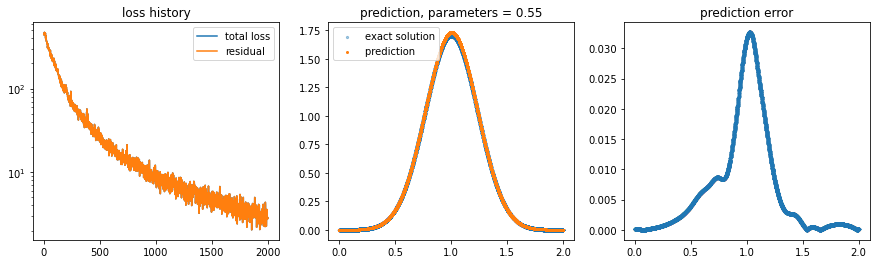

In [2]:
from pathlib import Path

from scimba.nets import training_tools
from scimba.pinns import pinn_losses, training_tx, pinn_tx
from scimba.sampling import (
    sampling_parameters,
    sampling_pde,
    uniform_sampling,
    sampling_ode,
)
from scimba.equations import domain


def main():
    xdomain = domain.SpaceDomain(1, domain.SquareDomain(1, [[0.0, 2.0]]))
    pde = ParamHeatPDE1D(tdomain=[0.0, 0.03], xdomain=xdomain)
    t_sampler = sampling_ode.TSampler(sampler=uniform_sampling.UniformSampling, ode=pde)
    x_sampler = sampling_pde.XSampler(pde=pde)
    mu_sampler = sampling_parameters.MuSampler(
        sampler=uniform_sampling.UniformSampling, model=pde
    )
    sampler = sampling_pde.PdeTXCartesianSampler(t_sampler, x_sampler, mu_sampler)

    file_name = "test.pth"
    new_training = True

    if new_training:
        (
            Path.cwd()
            / Path(training_tx.TrainerPINNSpaceTime.FOLDER_FOR_SAVED_NETWORKS)
            / file_name
        ).unlink(missing_ok=True)

    tlayers = [20, 80, 80, 80, 20, 10]
    network = pinn_tx.MLP_tx(pde=pde, layer_sizes=tlayers, activation_type="sine")
    pinn = pinn_tx.PINNtx(network, pde)

    losses = pinn_losses.PinnLossesData(w_res=1.0)
    optimizers = training_tools.OptimizerData(learning_rate=9e-3, decay=0.99)
    trainer = training_tx.TrainerPINNSpaceTime(
        pde=pde,
        network=pinn,
        losses=losses,
        optimizers=optimizers,
        sampler=sampler,
        file_name=file_name,
        batch_size=4000,
    )

    if new_training:
        trainer.train(epochs=2000, n_collocation=4000)

    trainer.plot(20000, reference_solution=True)


if __name__ == "__main__":
    main()


In [1]:
import torch
from pathlib import Path

from scimba.equations.domain import SpaceDomain, SquareDomain
from scimba.equations.pdes import AbstractPDEtx
from scimba.sampling import (
    sampling_parameters,
    sampling_pde,
    uniform_sampling,
    sampling_ode,
)
from scimba.pinns import pinn_tx, pinn_losses, training_tx
from scimba.nets import training_tools


class ParamHeatPDE_v2(AbstractPDEtx):
    """
    Heat equation with parameter α:
        ∂_t u - α ∂_xx u = 0,
    Dirichlet BC:
        u(t, xmin) = f(t)  (data driven),
        u(t, xmax) = 0.
    Initial condition:
        u(0, x) = sin(π x).
    """

    def __init__(self, xmin, xmax, t_bc, u_bc,
                 tdomain=(0.0, 0.03), p_domain=((0.4, 0.7),)):
        self.xmin, self.xmax = float(xmin), float(xmax)
        self.length = self.xmax - self.xmin

        # space domain
        xdomain = SpaceDomain(1, SquareDomain(1, [[self.xmin, self.xmax]]))
        super().__init__(
            nb_unknowns=1,
            time_domain=list(tdomain),
            space_domain=xdomain,
            nb_parameters=1,
            parameter_domain=p_domain,
        )

        # require u_t and u_xx
        self.first_derivative_t = True
        self.second_derivative_t = False
        self.first_derivative_x = False
        self.second_derivative_x = True

        # store & sort BC samples
        t_bc = torch.as_tensor(t_bc, dtype=torch.get_default_dtype())
        u_bc = torch.as_tensor(u_bc, dtype=torch.get_default_dtype())
        idx = torch.argsort(t_bc)
        self.t_bc = t_bc[idx]
        self.u_bc = u_bc[idx]

    def residual(self, w, t, x, mu, **kwargs):
        alpha = self.get_parameters(mu)
        u_t = self.get_variables(w, "w_t")
        u_xx = self.get_variables(w, "w_xx")
        return u_t - alpha * u_xx

    def bc_residual(self, w, t, x, mu, **kwargs):
        coords = x.get_coordinates().view(-1)
        u_val = self.get_variables(w).view(-1)

        mask_L = ((coords - self.xmin).abs() < 1e-8).float()
        mask_R = ((coords - self.xmax).abs() < 1e-8).float()

        f_t = torch.zeros_like(u_val)
        if mask_L.any():
            t_flat = t.view(-1)
            idxs = mask_L.bool()
            f_t[idxs] = self._interp_f(t_flat[idxs])

        res = mask_L * (u_val - f_t) + mask_R * u_val
        return res.view(-1, 1)

    @torch.no_grad()
    def _interp_f(self, t_q):
        t_q = t_q.clamp(self.t_bc[0], self.t_bc[-1])
        idx = torch.searchsorted(self.t_bc, t_q)
        idx1 = idx.clamp(1, len(self.t_bc) - 1)
        idx0 = idx1 - 1

        t0, t1 = self.t_bc[idx0], self.t_bc[idx1]
        u0, u1 = self.u_bc[idx0], self.u_bc[idx1]
        w = (t_q - t0) / (t1 - t0 + 1e-12)
        return u0 + w * (u1 - u0)

    def initial_condition(self, x, mu, **kwargs):
        coords = x.get_coordinates()
        return torch.sin(torch.pi * coords).view(-1, 1)

    def post_processing(self, t, x, mu, w):
        coords = x.get_coordinates().view(-1, 1)
        t_flat = t.view(-1, 1)
        L      = self.length

        # ---------- base term ----------
        weight_left = (self.xmax - coords) / L
        f_t  = self._interp_f(t_flat.view(-1)).view(-1, 1)
        f0   = self.u_bc[0]                      # 初值对应的 f(0)
        base = torch.sin(torch.pi * coords) + weight_left * (f_t - f0)

        # ---------- bump ----------
        bump = (coords - self.xmin) * (self.xmax - coords)
        return base + bump * w


    def reference_solution(self, t, x, mu):
        coords = x.get_coordinates().view(-1)
        alpha = self.get_parameters(mu).view(-1)
        u = torch.exp(-alpha * torch.pi**2 * t.view(-1)) * torch.sin(torch.pi * coords)
        return u.view(-1, 1)

Using device: cpu


In [1]:
import torch
from pathlib import Path

from scimba.equations.domain import SpaceDomain, SquareDomain
from scimba.equations.pdes import AbstractPDEtx
from scimba.sampling import (
    sampling_parameters,
    sampling_pde,
    uniform_sampling,
    sampling_ode,
)
from scimba.pinns import pinn_tx, pinn_losses, training_tx
from scimba.nets import training_tools

class ParamHeatPDE(AbstractPDEtx):
    """1D Heat PDE: u_t = α u_xx, with time‐varying Dirichlet on left and zero on right."""

    def __init__(self, xmin, xmax, t_bc, u_bc,
                 tdomain=(0.0, 0.03),   # time interval [t0, t_final]
                 p_domain=((0.4, 0.6),) # α ∈ [0.4, 0.6]
                 ):
        # spatial bounds
        self.xmin, self.xmax = float(xmin), float(xmax)
        self.length = self.xmax - self.xmin

        # build the space domain object
        xdomain = SpaceDomain(1, SquareDomain(1, [[self.xmin, self.xmax]]))
        super().__init__(
            nb_unknowns=1,           # u(x,t) only
            time_domain=list(tdomain),
            space_domain=xdomain,
            nb_parameters=1,         # thermal diffusivity α
            parameter_domain=p_domain
        )

        # request derivatives needed in residuals
        self.first_derivative_t  = True   # need u_t
        self.second_derivative_t = False  # no u_tt
        self.first_derivative_x  = True   # need u_x
        self.second_derivative_x = True   # need u_xx

        # set up boundary‐condition data
        self.update_bc(t_bc, u_bc)

    def residual(self, w, t, x, mu, **kwargs):
        """
        PDE residual: u_t - α u_xx == 0
        w: solution dict containing derivatives
        mu: parameter tensor for α
        """
        alpha = self.get_parameters(mu)
        u_t   = self.get_variables(w, "w_t")
        u_xx  = self.get_variables(w, "w_xx")
        return u_t - alpha * u_xx

    def bc_residual(self, w, t, x, mu, **kwargs):
        """
        Boundary residual mixes Dirichlet at xmin and homogeneous at xmax:
          u(xmin,t) = f(t)   and   u(xmax,t) = 0
        We mask points at each boundary.
        """
        coords = x.get_coordinates().view(-1)
        u_val  = self.get_variables(w).view(-1)

        # identify left / right boundary points
        mask_L = ((coords - self.xmin).abs() < 1e-8).float()
        mask_R = ((coords - self.xmax).abs() < 1e-8).float()

        # build target f(t) at xmin
        f_t = torch.zeros_like(u_val)
        if mask_L.any():
            t_flat = t.view(-1)
            idxs   = mask_L.bool()
            f_t[idxs] = self._interp_f(t_flat[idxs])

        # residual = mask_L*(u - f) + mask_R*(u - 0)
        res = mask_L * (u_val - f_t) + mask_R * u_val
        return res.view(-1, 1)

    @torch.no_grad()
    def _interp_f(self, t_q):
        """
        Linear interpolation of boundary data (t_bc, u_bc):
        clamp queries, find bracketing indices, and lerp.
        """
        t_q = t_q.clamp(self.t_bc[0], self.t_bc[-1])
        idx  = torch.searchsorted(self.t_bc, t_q)

        idx1 = idx.clamp(1, len(self.t_bc) - 1)
        idx0 = idx1 - 1

        t0, t1 = self.t_bc[idx0], self.t_bc[idx1]
        u0, u1 = self.u_bc[idx0], self.u_bc[idx1]
        w = (t_q - t0) / (t1 - t0 + 1e-12)  # avoid /0
        return u0 + w * (u1 - u0)

    def initial_condition(self, x, mu, **kwargs):
        """Initial temp: sin(π x) over the domain."""
        coords = x.get_coordinates()
        return torch.sin(torch.pi * coords).view(-1, 1)

    def post_processing(self, t, x, mu, w):
        """
        Enforce BCs analytically:
          u = base(x,t) + bump(x)*NN(x,t)
        base satisfies Dirichlet at xmin and default at xmax.
        bump vanishes at both ends.
        """
        coords = x.get_coordinates().view(-1, 1)
        t_flat = t.view(-1, 1)
        L      = self.length

        # weight → 1 at xmin, 0 at xmax
        weight_left = (self.xmax - coords) / L

        # interpolate f(t) at left
        f_t = self._interp_f(t_flat.view(-1)).view(-1, 1)
        f0  = self.u_bc[0]  # initial left‐BC value

        # base func: sin(πx) + weight*(f(t)-f0)
        base = torch.sin(torch.pi * coords) + weight_left * (f_t - f0)

        # bump = 0 at xmin & xmax
        bump = (coords - self.xmin) * (self.xmax - coords)

        return base + bump * w

    def reference_solution(self, t, x, mu):
        """
        Analytical solution for verification (0–1 domain, sin(π x) IC):
          u = exp(-α π² t) sin(π x)
        """
        coords = x.get_coordinates().view(-1)
        alpha  = self.get_parameters(mu).view(-1)
        u = torch.exp(-alpha * torch.pi**2 * t.view(-1)) * torch.sin(torch.pi * coords)
        return u.view(-1, 1)

    def update_bc(self, t_bc, u_bc):
        """Sort and store BC arrays as tensors."""
        t_bc = torch.as_tensor(t_bc, dtype=torch.get_default_dtype())
        u_bc = torch.as_tensor(u_bc, dtype=torch.get_default_dtype())
        idx  = torch.argsort(t_bc)
        self.t_bc, self.u_bc = t_bc[idx], u_bc[idx]

Using device: cpu


In [2]:
import numpy as np
# BC data at x = xmin
t_bc = [0.0, 0.01, 0.02, 0.03]
u_bc = np.exp(- 0.5 * np.pi**2 * np.array(t_bc)) * np.sin(np.pi * 0.5)
# u_bc = [1, 0.95, 0.90, 0.86]

# PDE instance
pde = ParamHeatPDE(
    xmin=0.5, xmax=1.0,
    t_bc=t_bc, u_bc=u_bc,
    tdomain=(0.0, 0.03),
    p_domain=((0.4, 0.6),),
)

# samplers
t_sampler = sampling_ode.TSampler(uniform_sampling.UniformSampling, ode=pde)
x_sampler = sampling_pde.XSampler(pde=pde)
mu_sampler = sampling_parameters.MuSampler(uniform_sampling.UniformSampling, model=pde)
sampler = sampling_pde.PdeTXCartesianSampler(t_sampler, x_sampler, mu_sampler)

# network & PINN
layers = [20, 80, 80, 80, 20, 10]
net = pinn_tx.MLP_tx(pde=pde, layer_sizes=layers, activation_type="sine")
pinn = pinn_tx.PINNtx(net, pde)

# losses & optimizer
losses = pinn_losses.PinnLossesData(
    init_loss_bool=True,
    bc_loss_bool=True,
    w_res=1.0,
    w_init=10.0,
    w_bc=5.0,
    # adaptive_weights="simple",   # 可选
    # epochs_adapt=20
)
optimizers = training_tools.OptimizerData(learning_rate=9e-3, decay=0.99)

# trainer setup
file_name = "param_heat_v2.pth"
save_dir = Path.cwd() / training_tx.TrainerPINNSpaceTime.FOLDER_FOR_SAVED_NETWORKS
(save_dir / file_name).unlink(missing_ok=True)

trainer = training_tx.TrainerPINNSpaceTime(
    pde=pde,
    network=pinn,
    losses=losses,
    optimizers=optimizers,
    sampler=sampler,
    file_name=file_name,
    batch_size=4000,
)

# train & plot
trainer.train(epochs=1000, n_collocation=4000)
#trainer.plot(n_points=20000, reference_solution=True)

>> load network /home/u4/csmi/2024/he/feelpp-scimba/MiniExamples/networks/param_heat_v2.pth
network was not loaded from file: training needed
epoch     0: current loss = 1.10e+01
epoch     0: best loss = 1.10e+01
epoch     1: best loss = 9.10e+00
epoch     2: best loss = 6.62e+00
epoch     3: best loss = 5.70e+00
epoch     4: best loss = 5.19e+00
epoch     5: best loss = 4.50e+00
epoch     6: best loss = 4.21e+00
epoch     7: best loss = 3.82e+00
epoch     8: best loss = 3.44e+00
epoch    10: best loss = 3.21e+00
epoch    11: best loss = 3.05e+00
epoch    13: best loss = 2.95e+00
epoch    15: best loss = 2.84e+00
epoch    16: best loss = 2.59e+00
epoch    17: best loss = 2.56e+00
epoch    19: best loss = 2.41e+00
epoch    20: best loss = 2.41e+00
epoch    22: best loss = 2.33e+00
epoch    23: best loss = 2.18e+00
epoch    24: best loss = 1.94e+00
epoch    25: best loss = 1.87e+00
epoch    28: best loss = 1.47e+00
epoch    29: best loss = 6.00e-01
epoch    32: best loss = 4.82e-01
epoch

/home/u4/csmi/2024/he/feelpp-scimba/.venv/lib/python3.10/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


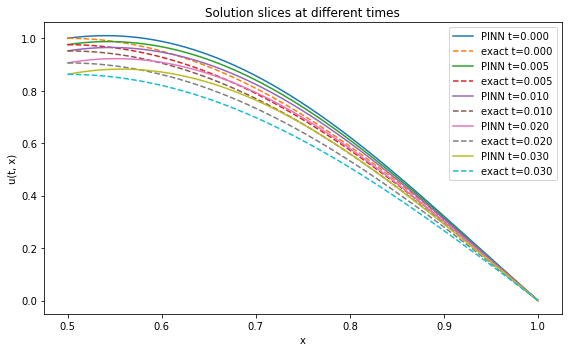

In [8]:
import torch
import matplotlib.pyplot as plt

def plot_time_slices(
    trainer,
    times=None,
    n_points=2000,
    reference_solution=False
):
    """
    Plot 1D PINN solution u(t, x) at multiple time points.

    Parameters
    ----------
    trainer : TrainerPINNSpaceTime
    times : list of float, optional
    n_points : int
    reference_solution : bool
    """
    pde = trainer.pde

    # Switch to eval mode
    trainer.network.eval()

    # Default time points
    if times is None:
        t_min, t_max = pde.time_domain
        times = [t_min, 0.5*(t_min+t_max), t_max]

    # μ fixed at midpoint
    mu_mid = torch.mean(torch.tensor(pde.parameter_domain), axis=1).unsqueeze(0)  # (1, nb_parameters)

    plt.figure(figsize=(8,5))
    for t_val in times:
        # Construct input
        t_tensor = torch.full((n_points,1), t_val)
        x_space  = trainer.sampler.sampling_x(n_points)
        mu_tensor= mu_mid.expand(n_points, pde.nb_parameters)

        # Prediction
        with torch.no_grad():
            w_dict = trainer.network.setup_w_dict(t_tensor, x_space, mu_tensor)
            u_pred = pde.post_processing(t_tensor, x_space, mu_tensor, w_dict["w"])[:,0]

            # If plotting reference solution
            if reference_solution and hasattr(pde, "reference_solution"):
                u_ref = pde.reference_solution(t_tensor, x_space, mu_tensor)[:,0]

        # Convert to numpy and sort
        x_coords = x_space.get_coordinates()[:,0].detach().cpu().numpy()
        idx = x_coords.argsort()
        u_np   = u_pred.detach().cpu().numpy()[idx]

        # Plot
        plt.plot(x_coords[idx], u_np, label=f"PINN t={t_val:.3f}")

        if reference_solution and hasattr(pde, "reference_solution"):
            u_ref_np = u_ref.detach().cpu().numpy()[idx]
            plt.plot(x_coords[idx], u_ref_np, "--", label=f"exact t={t_val:.3f}")

    plt.xlabel("x")
    plt.ylabel("u(t, x)")
    plt.title("Solution slices at different times")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_time_slices(
    trainer,
    times=[0.0, 0.005, 0.01, 0.02, 0.03],
    reference_solution=True
)